# Beam pre-processing experiment

## Data loading

In [2]:
import numpy as np

from scripts.data_filter import filter_dataframe
from scripts.data_loader import load_dataframe
from scripts.utils import NETWORK_TYPE
from scripts.weighted_coverage import run_weighted_coverage

filename = "5G_data_2023.mat"

# Series of random seeds for reproducability
random_seeds = np.loadtxt('data/random_seeds.csv', dtype=int)

# load the dataframe from saved file or 'raw' matlab file
df = load_dataframe(filename, NETWORK_TYPE._5G)

# # Drop unused columns to save space
matrix_cols_to_drop = ['toa_pps', 'toa_cir', 'toa_cov', 'campaign_id']
df['measurements_matrix'] = df['measurements_matrix'].apply(
    lambda x: x.drop(columns=matrix_cols_to_drop)
)

selected_campaigns = list(range(1, 121))
# Data filtering
df = filter_dataframe(
    df=df,
    include_columns=['pci', 'beam_index', 'nr_arfcn', 'operator_id', 'rsrq'],
    campaigns=selected_campaigns,
)

Loaded dataframe from .h5 file: /Users/andreres/Documents/UIO/master/thesis/dev/5G_localization/data/dataframe_cache/5G_data_2023.h5


In [3]:
d = []
import pandas as pd

ops = [1, 10, 50, 88]
for i, row in df.iterrows():
    res = row['measurements_matrix'].groupby('operator_id')['pci'].unique()

    res = (
        len(res[1]) if 1 in res.keys() else 0,
        len(res[10]) if 10 in res.keys() else 0,
        len(res[50]) if 50 in res.keys() else 0,
        len(res[88]) if 88 in res.keys() else 0)

    d.append(res)

t = pd.DataFrame(d, columns=ops)
m = t.melt(value_vars=ops, var_name='operator_id', value_name='pci')

{'1': '#004A98', '10': '#E60001', '50': '#22c55e', '88': '#a855f7'}


/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_35993/1445151523.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=m, x='operator_id', y='pci', palette=palette)


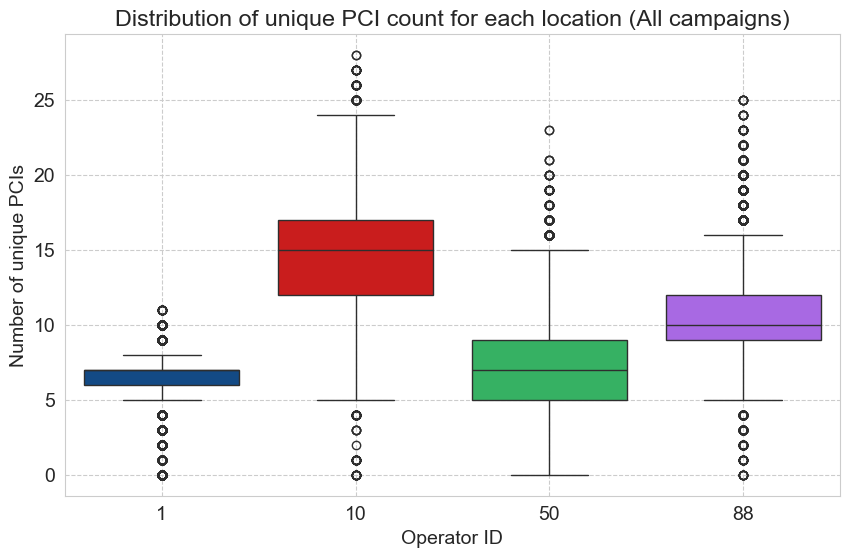


MIN
1     0
10    0
50    0
88    0
dtype: int64
MAX
1     11
10    28
50    23
88    25
dtype: int64
MEAN
1      6.447923
10    14.776456
50     7.264007
88    10.513463
dtype: float64



In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from scripts.utils import *

plt.rcParams['font.size'] = 14

plt.figure(figsize=(10, 6))
colors = get_config('color_map.json', 'operatorId')
print(colors)
palette = [v for k, v in colors.items()]
sns.boxplot(data=m, x='operator_id', y='pci', palette=palette)

plt.xlabel('Operator ID')
plt.ylabel('Number of unique PCIs')
plt.grid(linestyle='--')
plt.title('Distribution of unique PCI count for each location (All campaigns)')
plt.show()

print(f'''
MIN
{t.min()}
MAX
{t.max()}
MEAN
{t.mean()}
''')

In [1]:
t

NameError: name 't' is not defined

In [45]:
from scripts.beamforming import get_best_beam
from scripts.utils import RF_PARAM_5G

rf_param = RF_PARAM_5G.RSRQ

control_df = df.copy()

df['best_beam'] = df['measurements_matrix'].apply(lambda x: get_best_beam(x, rf_param))

In [3]:
unique_npcis = extract_unique_npcis(df["measurements_matrix"])

_, avg_error_control, _, _ = run_weighted_coverage(
    df=control_df,
    rf_param=rf_param,
    cluster_rf_param=rf_param,
    k_max=2,
    unique_npcis=unique_npcis,
    random_seed=42,
    n_clusters=0,
    use_beam_matching=False,
)

_, avg_error, _, _ = run_weighted_coverage(
    df=df,
    rf_param=rf_param,
    cluster_rf_param=rf_param,
    k_max=2,
    unique_npcis=unique_npcis,
    random_seed=42,
    n_clusters=0,
    use_beam_matching=True,
)

print(f"""
Beam matching {avg_error.mean()}
Control {avg_error_control.mean()}
""")

avg_error


Beam matching 7.773270602217144
Control 4.1594932655771535



array([ 1.64850577,  0.75519301,  3.18007487, ...,  6.66892206,
        0.04125774, 12.70208344])